# GOS Vision AI Assignment - Classify dog and cat images

## Import libraries

In [13]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import (
    DataLoader,
    random_split
)

from PIL import Image

## Check device

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


## Define transform

In [15]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Load dataset

In [16]:
DATASET_PATH = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Classes: ['Cat', 'Dog']
Total Images: 24998


## Train test split

In [17]:
train_size = int(0.7 * len(full_dataset))

valid_size = int(0.15 * len(full_dataset))

test_size = (
    len(full_dataset)
    - train_size
    - valid_size
)

train_dataset, valid_dataset, test_dataset = random_split(
    full_dataset,
    [
        train_size,
        valid_size,
        test_size
    ],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)}")
print(f"Valid: {len(valid_dataset)}")
print(f"Test : {len(test_dataset)}")

Train: 17498
Valid: 3749
Test : 3751


## Dataloader

In [18]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 547
Test batches: 118


## CNN Model

In [19]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 28 * 28, out_features=128),

            nn.ReLU(),
            nn.Linear(in_features=128, out_features=2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Optimizer

In [20]:
model = CatDogCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Training

In [21]:
epochs = 10

train_losses = []
train_accs = []

test_losses = []
test_accs = []

for epoch in range(epochs):

    # =====================
    # TRAIN
    # =====================
    model.train()

    running_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs} [Train]"
    )

    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (
            predicted == labels
        ).sum().item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*train_correct/train_total:.2f}%"
        )

    avg_train_loss = (running_loss / len(train_loader))
    train_acc = (train_correct / train_total)

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # =====================
    # VALIDATION / TEST
    # =====================
    model.eval()

    running_test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_test_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            test_total += labels.size(0)

            test_correct += (
                predicted == labels
            ).sum().item()

    avg_test_loss = (running_test_loss / len(test_loader))
    test_acc = (test_correct / test_total)

    test_losses.append(avg_test_loss)
    test_accs.append(test_acc)

    print(
        f"\nEpoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_acc:.4f} "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 [Train]: 100%|██████████| 547/547 [01:45<00:00,  5.16it/s, acc=62.55%, loss=0.5951]



Epoch [1/10] Train Acc: 0.6255 Test Acc: 0.7041


Epoch 2/10 [Train]: 100%|██████████| 547/547 [01:30<00:00,  6.07it/s, acc=71.83%, loss=0.6878]



Epoch [2/10] Train Acc: 0.7183 Test Acc: 0.7409


Epoch 3/10 [Train]: 100%|██████████| 547/547 [01:26<00:00,  6.31it/s, acc=77.01%, loss=0.3120]


...


Epoch [8/10] Train Acc: 0.9748 Test Acc: 0.7769


Epoch 9/10 [Train]: 100%|██████████| 547/547 [01:53<00:00,  4.84it/s, acc=98.34%, loss=0.0408]



Epoch [9/10] Train Acc: 0.9834 Test Acc: 0.7758


Epoch 10/10 [Train]: 100%|██████████| 547/547 [01:38<00:00,  5.57it/s, acc=98.69%, loss=0.1004]



Epoch [10/10] Train Acc: 0.9869 Test Acc: 0.7547


## Accuracy/Loss Curves

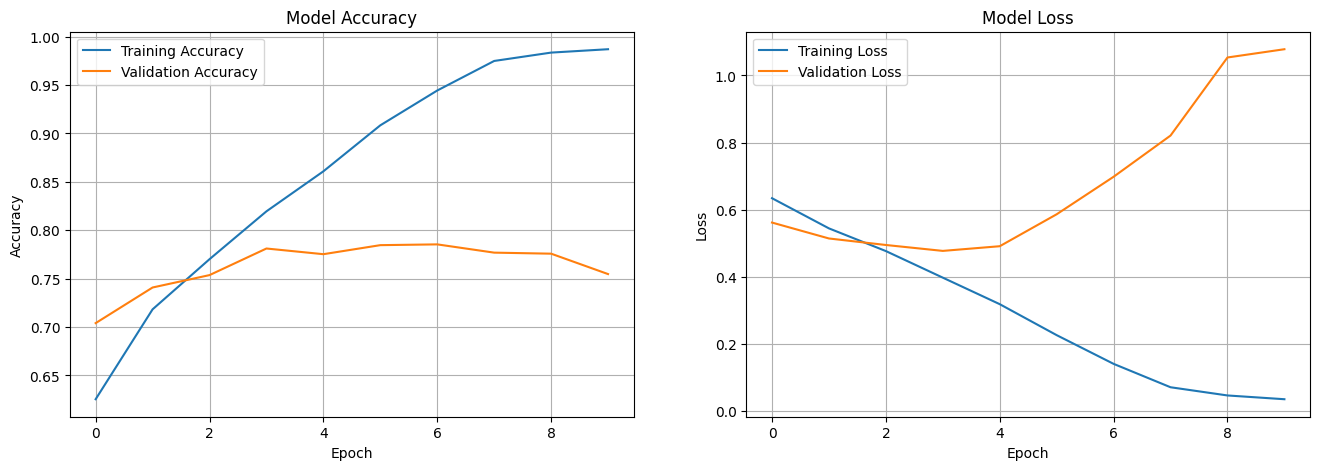

Final Training Accuracy: 0.9869
Final Validation Accuracy: 0.7547
Final Training Loss: 0.0362
Final Validation Loss: 1.0781


In [22]:
plt.figure(figsize=(16,5))

# =====================
# ACCURACY
# =====================
plt.subplot(1,2,1)
plt.plot(
    train_accs,
    label="Training Accuracy"
)

plt.plot(
    test_accs,
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# =====================
# LOSS
# =====================
plt.subplot(1,2,2)

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    test_losses,
    label="Validation Loss"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {test_accs[-1]:.4f}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {test_losses[-1]:.4f}")

## Save model

In [26]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": full_dataset.classes
    },
    "/kaggle/working/dog_cat_model_classification.pth"
)

print("Model saved!")

Model saved!


## Ramdom test

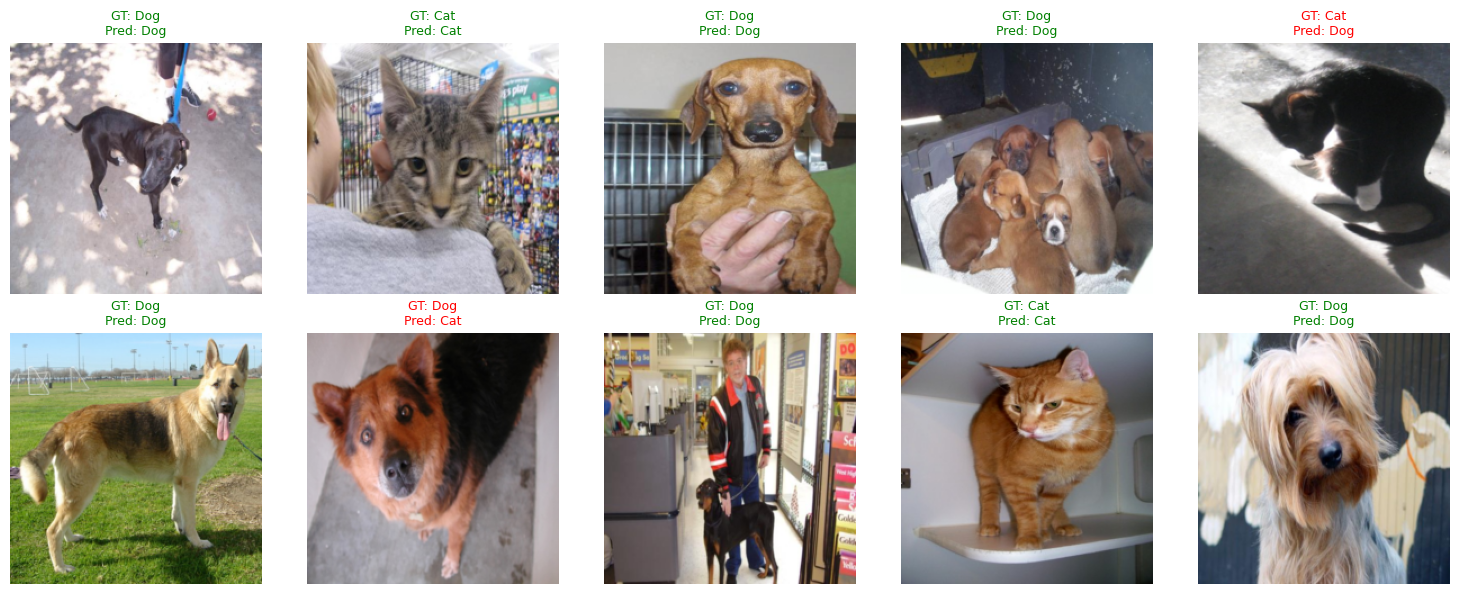

In [28]:
model.eval()

random_indices = random.sample(
    range(len(test_dataset)),
    10
)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(random_indices):
    image, label = test_dataset[idx]
    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = torch.argmax(
            output,
            dim=1
        )

    actual_class = full_dataset.classes[label]
    predicted_class = full_dataset.classes[pred.item()]

    is_correct = (
        actual_class == predicted_class
    )

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(
        f"GT: {actual_class}\nPred: {predicted_class}",
        color="green" if is_correct else "red",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()